# Green River Mammmoth Cave USGS Gauge Data (Site 03309000) Anlysis of flood events since removal of L&D6 (2018-2026)

In [1]:
## Installing libraries
# Install as needed.

%pip install pandas
%pip install numpy
%pip install matplotlib
%pip install requests

In [2]:
# Import Libraries and print Versions
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
import numpy as np
import os
import sys
import requests
import json

print("Python version: ", sys.version)
print("Pandas version: ", pd.__version__)
import matplotlib
print("Matplotlib version: ", matplotlib.__version__)
print("Numpy version: ", np.__version__)

print("OS name: ", os.name)
print("Current working directory: ", os.getcwd())
print("Python executable: ", sys.executable)
print("Python path: ", sys.path)
print("Python modules: ", sys.modules)
print("Python platform: ", sys.platform)
print("Python version: ", sys.version)
print("Python version info: ", sys.version_info)



Python version:  3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 08:22:19) [Clang 14.0.6 ]
Pandas version:  2.2.2
Matplotlib version:  3.9.2
Numpy version:  1.26.4
OS name:  posix
Current working directory:  /Users/raybies/CODE/GreenRiverFerryRiver
Python executable:  /opt/homebrew/anaconda3/bin/python
Python path:  ['/Users/raybies/CODE/GreenRiverFerryRiver', '/opt/homebrew/anaconda3/lib/python312.zip', '/opt/homebrew/anaconda3/lib/python3.12', '/opt/homebrew/anaconda3/lib/python3.12/lib-dynload', '', '/opt/homebrew/anaconda3/lib/python3.12/site-packages', '/opt/homebrew/anaconda3/lib/python3.12/site-packages/aeosa', '/opt/homebrew/anaconda3/lib/python3.12/site-packages/setuptools/_vendor']
Python modules:  {'sys': <module 'sys' (built-in)>, 'builtins': <module 'builtins' (built-in)>, '_frozen_importlib': <module '_frozen_importlib' (frozen)>, '_imp': <module '_imp' (built-in)>, '_thread': <module '_thread' (built-in)>, '_warnings': <module '_warnings' (built-in)>, '_weakref


Download USGS Gauge Data for Green River Mammoth Cave

In [3]:
## USGS Gauge Data
url = 'https://nwis.waterservices.usgs.gov/nwis/iv/?sites=03309000&agencyCd=USGS&startDT=2018-01-01T00:00:00.000-06:00&endDT=2026-02-24T23:59:59.999-05:00&parameterCd=00065&format=rdb'

try: 
    response = requests.get(url)
    response.raise_for_status()  # Raise an error for bad responses
except requests.exceptions.RequestException as e:
    print(f"Error: {e}")
    # Handle the error appropriately (e.g., log it, retry, etc.)
    exit()

Read the data that is in CSV into a dataframe

In [4]:
from io import StringIO

# Parse the response content and convert it into a DataFrame

# Decode the response content
content = response.content.decode('utf-8')

# Skip comment lines (lines starting with '#') and create a DataFrame
data_lines = "\n".join([line for line in content.splitlines() if not line.startswith('#')])
df = pd.read_csv(StringIO(data_lines), sep='\t')

# Display the first few rows of the DataFrame
print(df.head())

  agency_cd   site_no          datetime tz_cd 220645_00065 220645_00065_cd
0        5s       15s               20d    6s          14n             10s
1      USGS  03309000  2018-01-01 00:00   CST        20.20               A
2      USGS  03309000  2018-01-01 00:15   CST        20.19               A
3      USGS  03309000  2018-01-01 00:30   CST        20.19               A
4      USGS  03309000  2018-01-01 00:45   CST        20.17               A


/var/folders/vj/vdrtmr891czclg0wttpr4h2h0000gn/T/ipykernel_11302/1245403309.py:10: DtypeWarning: Columns (1,4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(StringIO(data_lines), sep='\t')


Convert data to date time and add new column that converts guage height to elevation

In [5]:
# Rename columns for clarity
df = df.rename(columns={"220645_00065_cd":"approved", "tz_cd":"timezone", "220645_00065":"gage"})

# Remove the first row of the DataFrame
df = df.iloc[1:]

# Reset the index of the DataFrame
df = df.reset_index(drop=True)

# Convert the 'dateTime' column to datetime format
df['datetime'] = pd.to_datetime(df['datetime'])
df['month'] = df['datetime'].dt.month
df['day'] = df['datetime'].dt.day
df['year'] = df['datetime'].dt.year

# Create a new DataFrame with the desired columns       
df2 = df[['datetime', 'gage', 'month', 'day', 'year']]

# Add 'height' column: gage + offset (use offset_ft defined in later cells)
offset_ft = 409.35
df2['height'] = pd.to_numeric(df2['gage'], errors='coerce') + offset_ft

# Display Data to check
df2.head()

/var/folders/vj/vdrtmr891czclg0wttpr4h2h0000gn/T/ipykernel_11302/579613124.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['height'] = pd.to_numeric(df2['gage'], errors='coerce') + offset_ft


,datetime,gage,month,day,year,height
0,2018-01-01 00:00:00,20.20,1,1,2018,429.55
1,2018-01-01 00:15:00,20.19,1,1,2018,429.54
2,2018-01-01 00:30:00,20.19,1,1,2018,429.54
3,2018-01-01 00:45:00,20.17,1,1,2018,429.52
4,2018-01-01 01:00:00,20.15,1,1,2018,429.50


Make a Box Plot of the Max Daily Guage Height, in elevation, for each month.

/var/folders/vj/vdrtmr891czclg0wttpr4h2h0000gn/T/ipykernel_11302/3961247329.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['gage'] = pd.to_numeric(df2['gage'], errors='coerce')
/var/folders/vj/vdrtmr891czclg0wttpr4h2h0000gn/T/ipykernel_11302/3961247329.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


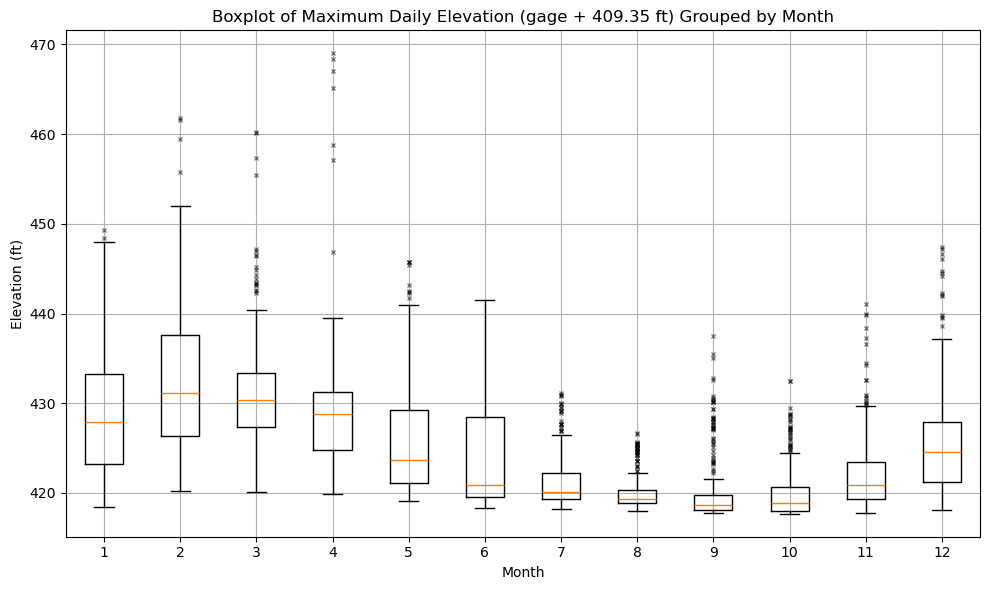

In [7]:
# Ensure the 'gage' column in df is numeric
df['gage'] = pd.to_numeric(df['gage'], errors='coerce')

# Ensure the 'gage' column in df2 is numeric
df2['gage'] = pd.to_numeric(df2['gage'], errors='coerce')

# Create a DataFrame of the maximum gauge value for each day
daily_max_df = df.groupby(df['datetime'].dt.date)['gage'].max().reset_index()
daily_max_df.columns = ['date', 'max_daily_gage']

# Add a month column to the daily_max_df
daily_max_df['month'] = pd.to_datetime(daily_max_df['date']).dt.month

# Apply vertical offset in feet (convert gage to elevation):
offset_ft = 409.35
daily_max_df['max_daily_elev_ft'] = daily_max_df['max_daily_gage'] + offset_ft

# Group the maximum daily elevation by month
grouped_daily_max = daily_max_df.groupby('month')['max_daily_elev_ft']

# Create a boxplot of the maximum daily elevations grouped by month
plt.figure(figsize=(10, 6))
plt.boxplot(
    [group for _, group in grouped_daily_max],
    labels=grouped_daily_max.groups.keys(),
    flierprops={
        'marker': 'x',  # Outlier marker symbol
        'markerfacecolor': 'red',  # Outlier marker color
        'markeredgecolor': 'black',  # Outlier marker edge color
        'markersize': 3,  # Outlier marker size
        'alpha': 0.5  # Outlier opacity
    }
)
plt.title('Boxplot of Maximum Daily Elevation (gage + 409.35 ft) Grouped by Month')
plt.xlabel('Month')
plt.ylabel('Elevation (ft)')
plt.grid(True)
plt.tight_layout()
plt.show()

Make a Box Plot of the Max Daily Guage Height for each month.

/var/folders/vj/vdrtmr891czclg0wttpr4h2h0000gn/T/ipykernel_11302/3519027179.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['gage'] = pd.to_numeric(df2['gage'], errors='coerce')
/var/folders/vj/vdrtmr891czclg0wttpr4h2h0000gn/T/ipykernel_11302/3519027179.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


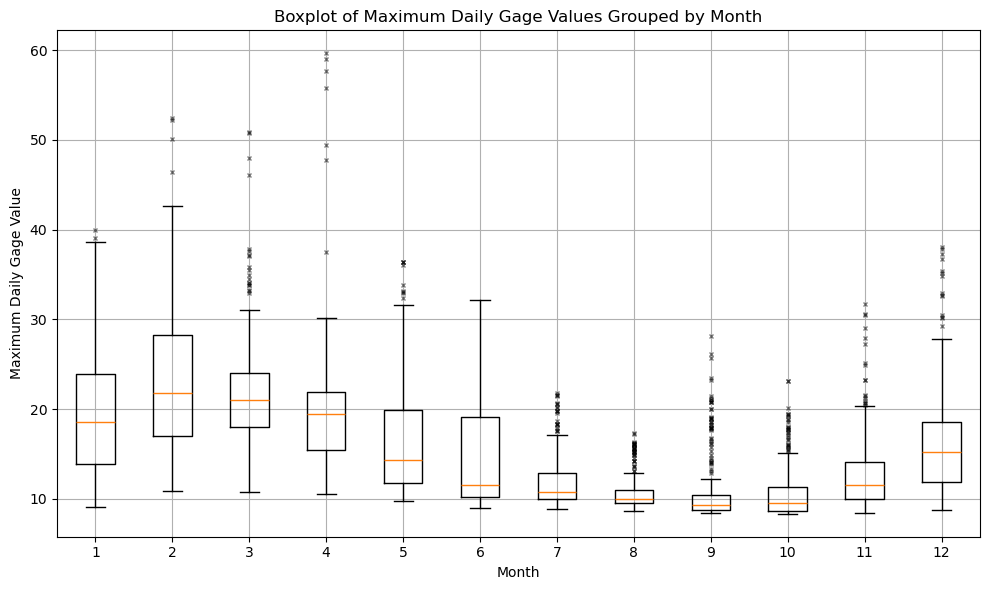

In [8]:
# Ensure the 'gage' column in df is numeric
df['gage'] = pd.to_numeric(df['gage'], errors='coerce')

# Ensure the 'gage' column in df2 is numeric
df2['gage'] = pd.to_numeric(df2['gage'], errors='coerce')

# Create a DataFrame of the maximum gauge value for each day
daily_max_df = df.groupby(df['datetime'].dt.date)['gage'].max().reset_index()
daily_max_df.columns = ['date', 'max_daily_gage']

# Add a month column to the daily_max_df
daily_max_df['month'] = pd.to_datetime(daily_max_df['date']).dt.month

# Group the maximum daily values by month
grouped_daily_max = daily_max_df.groupby('month')['max_daily_gage']

# Create a boxplot of the maximum daily values grouped by month
plt.figure(figsize=(10, 6))
plt.boxplot(
    [group for _, group in grouped_daily_max],
    labels=grouped_daily_max.groups.keys(),
    flierprops={
        'marker': 'x',  # Outlier marker symbol
        'markerfacecolor': 'red',  # Outlier marker color
        'markeredgecolor': 'black',  # Outlier marker edge color
        'markersize': 3,  # Outlier marker size
        'alpha': 0.5  # Outlier opacity
    }
)
plt.title('Boxplot of Maximum Daily Gage Values Grouped by Month')
plt.xlabel('Month')
plt.ylabel('Maximum Daily Gage Value')
plt.grid(True)
plt.tight_layout()
plt.show()


Box Plot of Guage by year.

/var/folders/vj/vdrtmr891czclg0wttpr4h2h0000gn/T/ipykernel_11302/1953985165.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['gage'] = pd.to_numeric(df2['gage'], errors='coerce')
/var/folders/vj/vdrtmr891czclg0wttpr4h2h0000gn/T/ipykernel_11302/1953985165.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


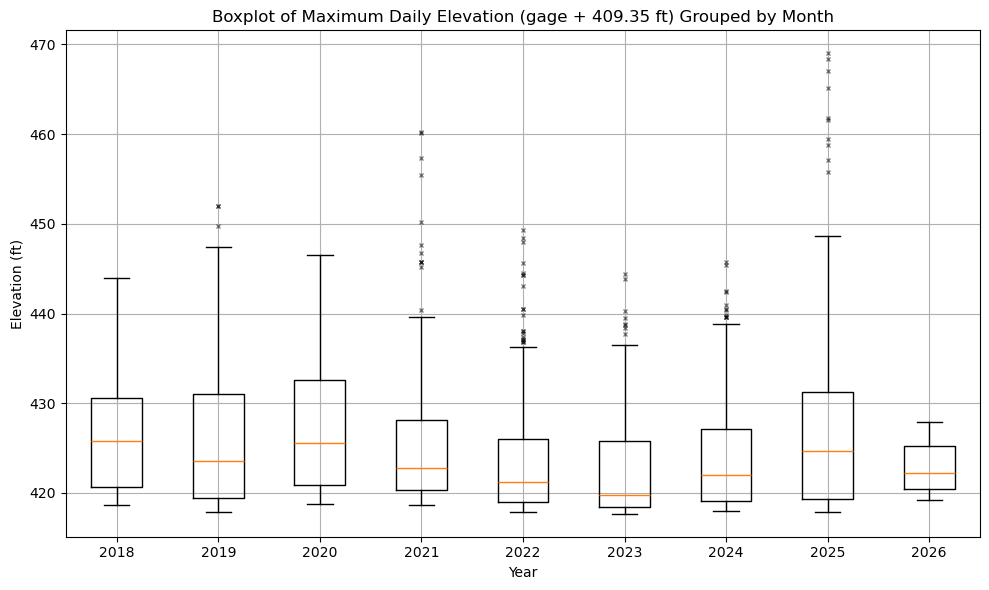

In [11]:
# Ensure the 'gage' column in df is numeric
df['gage'] = pd.to_numeric(df['gage'], errors='coerce')

# Ensure the 'gage' column in df2 is numeric
df2['gage'] = pd.to_numeric(df2['gage'], errors='coerce')

# Create a DataFrame of the maximum gauge value for each day
daily_max_df = df.groupby(df['datetime'].dt.date)['gage'].max().reset_index()
daily_max_df.columns = ['date', 'max_daily_gage']

# Add a month column to the daily_max_df
daily_max_df['year'] = pd.to_datetime(daily_max_df['date']).dt.year

# Apply vertical offset in feet (convert gage to elevation):
offset_ft = 409.35
daily_max_df['max_daily_elev_ft'] = daily_max_df['max_daily_gage'] + offset_ft

# Group the maximum daily elevation by month
grouped_daily_max = daily_max_df.groupby('year')['max_daily_elev_ft']

# Create a boxplot of the maximum daily elevations grouped by month
plt.figure(figsize=(10, 6))
plt.boxplot(
    [group for _, group in grouped_daily_max],
    labels=grouped_daily_max.groups.keys(),
    flierprops={
        'marker': 'x',  # Outlier marker symbol
        'markerfacecolor': 'red',  # Outlier marker color
        'markeredgecolor': 'black',  # Outlier marker edge color
        'markersize': 3,  # Outlier marker size
        'alpha': 0.5  # Outlier opacity
    }
)
plt.title('Boxplot of Maximum Daily Elevation (gage + 409.35 ft) Grouped by Year')
plt.xlabel('Year')
plt.ylabel('Elevation (ft)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
print(daily_max_df)

Filter Out Events over bottom bridge heights

In [12]:
# Ensure elevation column exists, then filter for >= 477 ft the 500 year flood level
if 'max_daily_elev_ft' not in daily_max_df.columns:
    daily_max_df['max_daily_elev_ft'] = daily_max_df['max_daily_gage'] + offset_ft

df_477 = daily_max_df[daily_max_df['max_daily_elev_ft'] >= 477].reset_index(drop=True)
df_477

,date,max_daily_gage,year,max_daily_elev_ft


In [29]:


# Sort by date to ensure proper sequence detection
df_477_sorted = df_477.sort_values('date').reset_index(drop=True)

# Calculate the difference between consecutive dates
df_477_sorted['date_diff'] = df_477_sorted['date'].diff().dt.days

# Identify event breaks (where date difference > 1 day)
df_477_sorted['event_id'] = (df_477_sorted['date_diff'] > 1).cumsum()

# Count events and days per event
event_summary = df_477_sorted.groupby('event_id').agg(
    event_start=('date', 'min'),
    event_end=('date', 'max'),
    num_days=('date', 'count'),
    max_elevation=('max_daily_elev_ft', 'max')
).reset_index(drop=True)

# Renumber events starting from 1
event_summary.insert(0, 'event_num', range(1, len(event_summary) + 1))

print(f"Total number of events: {len(event_summary)}")
print(f"\n{event_summary}")

AttributeError: Can only use .dt accessor with datetimelike values

In [30]:
# Ensure elevation column exists, then filter for >= 470 ft the 100 year flood level
if 'max_daily_elev_ft' not in daily_max_df.columns:
    daily_max_df['max_daily_elev_ft'] = daily_max_df['max_daily_gage'] + offset_ft

df_470 = daily_max_df[daily_max_df['max_daily_elev_ft'] >= 470].reset_index(drop=True)
df_470

,date,max_daily_gage,year,max_daily_elev_ft


In [31]:


# Sort by date to ensure proper sequence detection
df_470_sorted = df_470.sort_values('date').reset_index(drop=True)

# Calculate the difference between consecutive dates
df_470_sorted['date_diff'] = df_470_sorted['date'].diff().dt.days

# Identify event breaks (where date difference > 1 day)
df_470_sorted['event_id'] = (df_470_sorted['date_diff'] > 1).cumsum()

# Count events and days per event
event_summary = df_470_sorted.groupby('event_id').agg(
    event_start=('date', 'min'),
    event_end=('date', 'max'),
    num_days=('date', 'count'),
    max_elevation=('max_daily_elev_ft', 'max')
).reset_index(drop=True)

# Renumber events starting from 1
event_summary.insert(0, 'event_num', range(1, len(event_summary) + 1))

print(f"Total number of events: {len(event_summary)}")
print(f"\n{event_summary}")

AttributeError: Can only use .dt accessor with datetimelike values

In [32]:
# Ensure elevation column exists, then filter for >= 455 ft, the 100 year flood level
if 'max_daily_elev_ft' not in daily_max_df.columns:
    daily_max_df['max_daily_elev_ft'] = daily_max_df['max_daily_gage'] + offset_ft

df_455 = daily_max_df[daily_max_df['max_daily_elev_ft'] >= 455].reset_index(drop=True)
print(df_455)
df_455.describe()

          date  max_daily_gage  year  max_daily_elev_ft
0   2021-03-01           46.12  2021             455.47
1   2021-03-02           50.76  2021             460.11
2   2021-03-03           50.94  2021             460.29
3   2021-03-04           48.02  2021             457.37
4   2025-02-16           46.46  2025             455.81
5   2025-02-17           52.26  2025             461.61
6   2025-02-18           52.46  2025             461.81
7   2025-02-19           50.07  2025             459.42
8   2025-04-04           47.73  2025             457.08
9   2025-04-05           57.67  2025             467.02
10  2025-04-06           59.66  2025             469.01
11  2025-04-07           58.99  2025             468.34
12  2025-04-08           55.82  2025             465.17
13  2025-04-09           49.47  2025             458.82


,max_daily_gage,year,max_daily_elev_ft
count,14.000000,14.000000,14.000000
mean,51.887857,2023.857143,461.237857
std,4.527747,1.875229,4.527747
min,46.120000,2021.000000,455.470000
25%,48.382500,2022.000000,457.732500
50%,50.850000,2025.000000,460.200000
75%,54.980000,2025.000000,464.330000
max,59.660000,2025.000000,469.010000


In [ ]:


# Sort by date to ensure proper sequence detection
df_455_sorted = df_455.sort_values('date').reset_index(drop=True)

# Calculate the difference between consecutive dates
df_455_sorted['date_diff'] = df_455_sorted['date'].diff().dt.days

# Identify event breaks (where date difference > 1 day)
df_455_sorted['event_id'] = (df_455_sorted['date_diff'] > 1).cumsum()

# Count events and days per event
event_summary_455 = df_455_sorted.groupby('event_id').agg(
    event_start=('date', 'min'),
    event_end=('date', 'max'),
    num_days=('date', 'count'),
    max_elevation=('max_daily_elev_ft', 'max')
).reset_index(drop=True)

# Renumber events starting from 1
event_summary_445.insert(0, 'event_num', range(1, len(event_summary_445) + 1))

print(f"Total number of events where river level was 455 feet and greater: {len(event_summary_445)}")
print(f"\n{event_summary_445}")

Total number of events where river level was 455 feet and greater: 3

   event_num event_start   event_end  num_days  max_elevation
0          1  2021-03-01  2021-03-04         4         460.29
1          2  2025-02-16  2025-02-19         4         461.81
2          3  2025-04-04  2025-04-09         6         469.01


In [23]:
# Ensure elevation column exists, then filter for >= 443 ft
if 'max_daily_elev_ft' not in daily_max_df.columns:
    daily_max_df['max_daily_elev_ft'] = daily_max_df['max_daily_gage'] + offset_ft

df_443 = daily_max_df[daily_max_df['max_daily_elev_ft'].between(443,455)].reset_index(drop=True)
print(df_443)
df_443.describe()

          date  max_daily_gage  year  max_daily_elev_ft
0   2018-02-12           34.60  2018             443.95
1   2018-02-13           34.17  2018             443.52
2   2018-03-30           33.88  2018             443.23
3   2018-03-31           33.78  2018             443.13
4   2019-01-01           34.16  2019             443.51
..         ...             ...   ...                ...
61  2025-03-16           34.08  2025             443.43
62  2025-03-17           37.87  2025             447.22
63  2025-03-18           37.67  2025             447.02
64  2025-04-10           37.50  2025             446.85
65  2025-05-18           33.81  2025             443.16

[66 rows x 4 columns]


,max_daily_gage,year,max_daily_elev_ft
count,66.000000,66.000000,66.000000
mean,36.216818,2020.818182,445.566818
std,2.061514,2.169077,2.061514
min,33.740000,2018.000000,443.090000
25%,34.510000,2019.000000,443.860000
50%,35.950000,2020.000000,445.300000
75%,37.182500,2022.000000,446.532500
max,42.620000,2025.000000,451.970000


Total number of events where river level was 443 feet and greater: 30

    event_num event_start   event_end  num_days  max_elevation
0           1  2018-02-12  2018-02-13         2         443.95
1           2  2018-03-30  2018-03-31         2         443.23
2           3  2019-01-01  2019-01-02         2         443.89
3           4  2019-02-08  2019-02-09         2         443.48
4           5  2019-02-12  2019-02-14         3         446.42
5           6  2019-02-21  2019-02-22         2         446.39
6           7  2019-02-24  2019-02-27         4         451.97
7           8  2019-12-01  2019-12-03         3         446.60
8           9  2019-12-17  2019-12-19         3         447.39
9          10  2019-12-31  2020-01-01         2         444.74
10         11  2020-02-05  2020-02-07         3         445.54
11         12  2020-02-12  2020-02-15         4         444.90
12         13  2020-03-04  2020-03-05         2         446.57
13         14  2020-03-14  2020-03-14         1

/var/folders/vj/vdrtmr891czclg0wttpr4h2h0000gn/T/ipykernel_11302/711953970.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


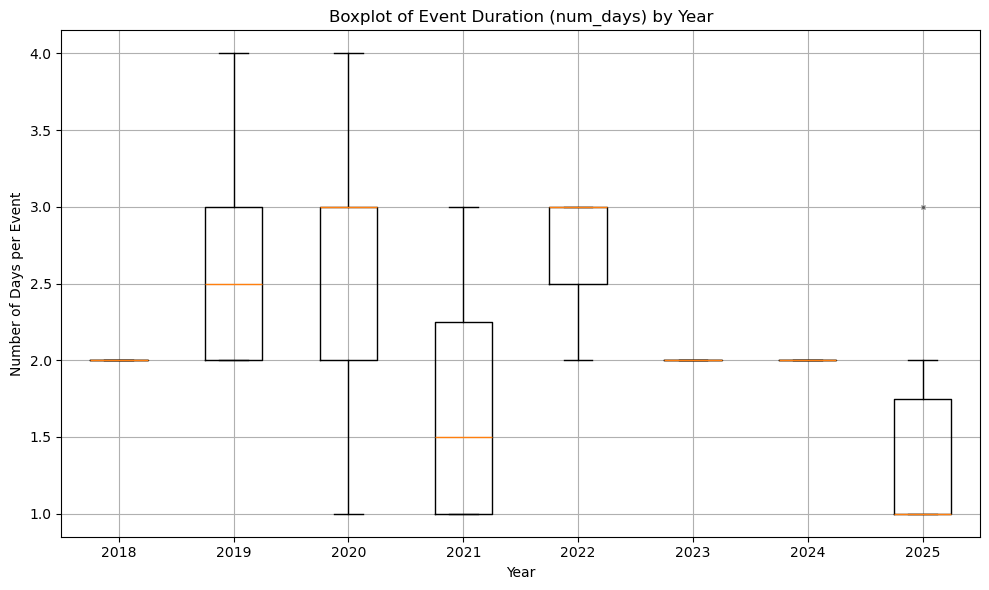

In [ ]:
# Sort by date to ensure proper sequence detection
df_443_sorted = df_443.sort_values('date').reset_index(drop=True)

# Calculate the difference between consecutive dates
df_443_sorted['date_diff'] = df_443_sorted['date'].diff().dt.days

# Identify event breaks (where date difference > 1 day)
df_443_sorted['event_id'] = (df_443_sorted['date_diff'] > 1).cumsum()

# Count events and days per event
event_summary_443 = df_443_sorted.groupby('event_id').agg(
    event_start=('date', 'min'),
    event_end=('date', 'max'),
    num_days=('date', 'count'),
    max_elevation=('max_daily_elev_ft', 'max')
).reset_index(drop=True)

# Renumber events starting from 1
event_summary_443.insert(0, 'event_num', range(1, len(event_summary_443) + 1))

print(f"Total number of events where river level was 443 feet and greater: {len(event_summary_443)}")
print(f"\n{event_summary_443}")

# use the already‑computed `event_summary` (last one is for the 443 ft threshold)
# add a year column so we can group by it
event_summary_by_year = event_summary_443.copy()
event_summary_by_year['year'] = pd.to_datetime(event_summary_by_year['event_start']).dt.year

# group the event durations by year and make a boxplot
grouped_year = event_summary_by_year.groupby('year')['num_days']

plt.figure(figsize=(10, 6))
plt.boxplot(
    [grp for _, grp in grouped_year],
    labels=grouped_year.groups.keys(),
    flierprops={'marker': 'x', 'markerfacecolor': 'red',
                'markeredgecolor': 'black', 'markersize': 3, 'alpha': 0.5}
)
plt.title('Boxplot of Event Duration (num_days) by Year')
plt.xlabel('Year')
plt.ylabel('Number of Days per Event')
plt.grid(True)
plt.tight_layout()
plt.show()

/var/folders/vj/vdrtmr891czclg0wttpr4h2h0000gn/T/ipykernel_11302/3451841120.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


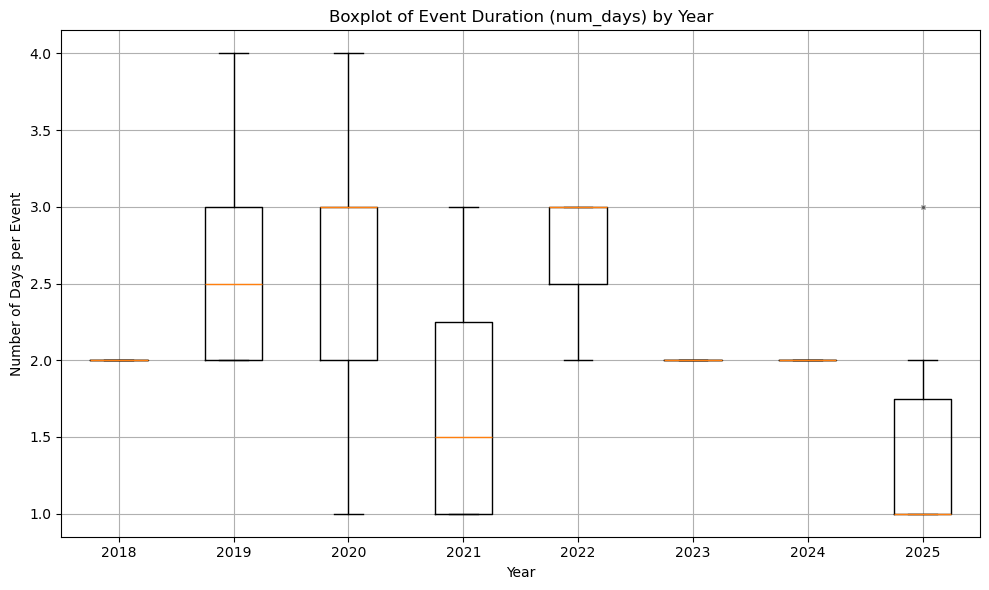

In [43]:
# use the already‑computed `event_summary` (last one is for the 443 ft threshold)
# add a year column so we can group by it
event_summary_by_year = event_summary_443.copy()
event_summary_by_year['year'] = pd.to_datetime(event_summary_by_year['event_start']).dt.year

# group the event durations by year and make a boxplot
grouped_year = event_summary_by_year.groupby('year')['num_days']

plt.figure(figsize=(10, 6))
plt.boxplot(
    [grp for _, grp in grouped_year],
    labels=grouped_year.groups.keys(),
    flierprops={'marker': 'x', 'markerfacecolor': 'red',
                'markeredgecolor': 'black', 'markersize': 3, 'alpha': 0.5}
)
plt.title('Boxplot of Event Duration (num_days) by Year')
plt.xlabel('Year')
plt.ylabel('Number of Days per Event')
plt.grid(True)
plt.tight_layout()
plt.show()

In [24]:
# Ensure elevation column exists, then filter for >= 435 ft
if 'max_daily_elev_ft' not in daily_max_df.columns:
    daily_max_df['max_daily_elev_ft'] = daily_max_df['max_daily_gage'] + offset_ft

df_435 = daily_max_df[daily_max_df['max_daily_elev_ft'].between(435,443)].reset_index(drop=True)
print(df_435)
df_435.describe()

           date  max_daily_gage  year  max_daily_elev_ft
0    2018-02-08           27.36  2018             436.71
1    2018-02-09           26.64  2018             435.99
2    2018-02-11           32.71  2018             442.06
3    2018-02-18           28.27  2018             437.62
4    2018-02-19           28.25  2018             437.60
..          ...             ...   ...                ...
155  2025-06-18           27.56  2025             436.91
156  2025-06-19           31.81  2025             441.16
157  2025-06-20           32.16  2025             441.51
158  2025-06-21           31.54  2025             440.89
159  2025-06-22           25.88  2025             435.23

[160 rows x 4 columns]


,max_daily_gage,year,max_daily_elev_ft
count,160.000000,160.000000,160.000000
mean,28.789313,2021.156250,438.139313
std,2.179850,2.430278,2.179850
min,25.650000,2018.000000,435.000000
25%,27.142500,2019.000000,436.492500
50%,28.375000,2020.000000,437.725000
75%,30.337500,2023.000000,439.687500
max,33.620000,2025.000000,442.970000


Evalulate the number of flood events with the lenght of the event and max river height durring event.

In [ ]:
# Sort by date to ensure proper sequence detection
df_435_sorted = df_435.sort_values('date').reset_index(drop=True)

# Calculate the difference between consecutive dates
df_435_sorted['date_diff'] = df_435_sorted['date'].diff().dt.days

# Identify event breaks (where date difference > 1 day)
df_435_sorted['event_id'] = (df_435_sorted['date_diff'] > 1).cumsum()

# Count events and days per event
event_summary_435 = df_435_sorted.groupby('event_id').agg(
    event_start=('date', 'min'),
    event_end=('date', 'max'),
    num_days=('date', 'count'),
    max_elevation=('max_daily_elev_ft', 'max')
).reset_index(drop=True)

# Renumber events starting from 1
event_summary_435.insert(0, 'event_num', range(1, len(event_summary_435) + 1))

print(f"Total number of events where river level was 435 feet and greater: {len(event_summary_435)}")

print(f"\n{event_summary_435}")

Total number of events where river level was 435 feet and greater: 80

    event_num event_start   event_end  num_days  max_elevation
0           1  2018-02-08  2018-02-09         2         436.71
1           2  2018-02-11  2018-02-11         1         442.06
2           3  2018-02-18  2018-02-19         2         437.62
3           4  2018-02-22  2018-02-27         6         442.97
4           5  2018-03-25  2018-03-26         2         437.44
..        ...         ...         ...       ...            ...
75         76  2025-05-04  2025-05-06         3         438.80
76         77  2025-05-17  2025-05-17         1         442.25
77         78  2025-05-19  2025-05-19         1         440.79
78         79  2025-05-21  2025-05-23         3         441.73
79         80  2025-06-17  2025-06-22         6         441.51

[80 rows x 5 columns]


/var/folders/vj/vdrtmr891czclg0wttpr4h2h0000gn/T/ipykernel_11302/1564772800.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


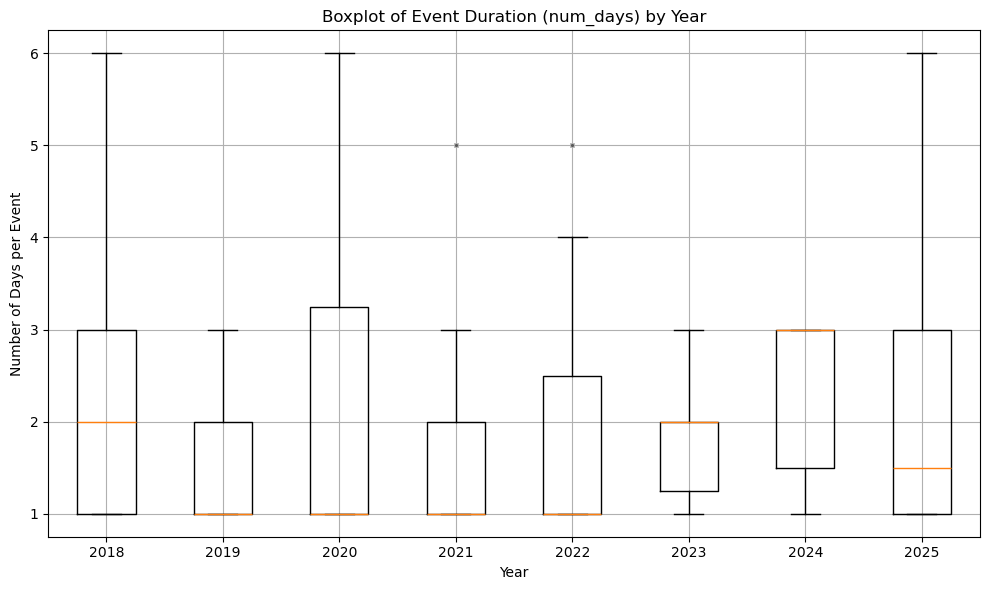

In [41]:
# use the already‑computed `event_summary` (last one is for the 435 ft threshold)
# add a year column so we can group by it
event_summary_by_year = event_summary_435.copy()
event_summary_by_year['year'] = pd.to_datetime(event_summary_by_year['event_start']).dt.year

# group the event durations by year and make a boxplot
grouped_year = event_summary_by_year.groupby('year')['num_days']

plt.figure(figsize=(10, 6))
plt.boxplot(
    [grp for _, grp in grouped_year],
    labels=grouped_year.groups.keys(),
    flierprops={'marker': 'x', 'markerfacecolor': 'red',
                'markeredgecolor': 'black', 'markersize': 3, 'alpha': 0.5}
)
plt.title('Boxplot of Event Duration (num_days) by Year')
plt.xlabel('Year')
plt.ylabel('Number of Days per Event')
plt.grid(True)
plt.tight_layout()
plt.show()